# One QP, five solvers: the PIQP library, the generated PIQP, and IPOPT

Scaly now generates PIQP itself: `scaly.solvers.ipm` writes PIQP 0.6.2's proximal interior-point
method (Ruiz equilibration, the initial point, the Mehrotra predictor–corrector with proximal
$\rho,\delta$ updates, unscaling) as C specialised to one sparsity structure, with no library behind
it. This notebook puts it next to the two library solvers Scaly already drives, on four QP families
written once each as a parametric `sc.opt.problem`:

| Solver | Built by | What the generated C contains |
| --- | --- | --- |
| PIQP library, sparse / dense | `sc.opt.solver(problem, sc.opt.PIQP(sparse=...))` | the QP data as oracles of the parameters, and a call into the vendored PIQP 0.6.2 (C++, Eigen, BLASFEO) |
| generated PIQP, sparse / dense | `generated_piqp.solver(problem, backend)` | the whole solver: `SparseLDL` on the full KKT matrix, or a condensed Cholesky |
| IPOPT | `sc.opt.solver(problem, "ipopt")` | oracles, and a call into the vendored IPOPT 3.14 with MUMPS |

All three take the same parameters and return the same `x`. Each (problem, solver) pair runs in a
fresh process with an empty JIT cache (`compare.py`), and we measure what it costs to get a solver
(build in Python, generate C, compile), how big it is, how fast it solves, and what it returns. Solve
times are taken in C by `time_entry.c`, which calls the generated entry point directly, so no Python
is in the loop; every solve is cold (PIQP 0.6.2 has no warm start, and none is given to the others).
The C of every solver is written to `examples/generated/qp_solvers/<problem>/<solver>/`.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent / "notebooks"))
import plotstyle

import compare
import generated_piqp
import problems

plotstyle.use()
RESULTS = Path("build") / "results.json"
RERUN = not RESULTS.exists()  # set True to measure again: about 15 minutes, one process per cell
if RERUN:
  compare.run(out=RESULTS, budget=2.0)
res = json.loads(RESULTS.read_text())
rows = {(r["case"], r["solver"]): r for r in res["rows"]}
for k, v in res["machine"].items():
  print(f"{k:>9}: {v}")
failed = [r for r in res["rows"] if "failed" in r]
print(f"{len(res['rows'])} cells, {len(failed)} failed", *(f"\n  {r['case']} {r['solver']}: {r['failed']}" for r in failed))

 platform: Linux-6.18.44-fc-v42-x86_64-with-glibc2.39
      cpu: Intel(R) Xeon(R) Processor @ 2.10GHz
 compiler: cc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0
    flags: -O2 -march=native -fno-math-errno
   python: 3.14.0rc2
42 cells, 0 failed


In [2]:
SOLVERS = list(compare.SOLVERS)
LABEL = compare.SOLVERS
COLOR = dict(zip(SOLVERS, plotstyle.SERIES))
CASES = ["mpc_N20", "portfolio", "svm", "dense"]
SWEEP = ["mpc_N5", "mpc_N10", "mpc_N20", "mpc_N40"]
ALL = problems.cases() | {c.name: c for c in (problems.mpc(n) for n in (5, 10, 40))}


def table(header, body):
  # A Markdown table in Jupyter, plain text elsewhere.
  lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)] + ["| " + " | ".join(map(str, r)) + " |" for r in body]
  try:
    from IPython.display import Markdown, display

    display(Markdown("\n".join(lines)))
  except ImportError:
    print("\n".join(lines))


def us(s):
  return f"{1e6 * s:,.0f} µs" if s < 1e-2 else f"{1e3 * s:,.1f} ms"

## The problems

| Case | Structure | Run-time parameters |
| --- | --- | --- |
| `mpc_N20` | oscillating masses (4 masses, 3 actuators), sparse multiple shooting over $N = 20$ steps: banded dynamics equalities, boxes on inputs and positions | $x_0$ (only $b$ changes) |
| `portfolio` | Markowitz with a factor risk model, $\min \gamma(\lVert y\rVert^2 + x^\top D x) - \mu^\top x$ s.t. $y = F^\top x$, $\mathbf 1^\top x = 1$, $0 \le x \le 0.1$ | $\mu, F, D, \gamma$ ($P$, $c$, $A$) |
| `svm` | soft-margin SVM, $\min \tfrac12\lVert w\rVert^2 + \mathbf 1^\top t$ s.t. $y_i(a_i^\top w + b) + t_i \ge 1$, $t \ge 0$ | the samples and labels ($G$) |
| `dense` | `sc.opt.QP(30, 5, 40)`: every matrix a dense parameter, two-sided inequalities | everything |

The sizes below are those of the QP Scaly extracts: $n$ variables, $p$ equalities, $m$ inequality
rows (box bounds on $x$ are separate and not counted in $m$), and the stored entries of $P$ (upper
triangle), $A$ and $G$.

In [3]:
body = []
for name in CASES + ["mpc_N5", "mpc_N10", "mpc_N40"]:
  s = generated_piqp.structure_summary(ALL[name].problem)
  body.append([f"`{name}`", ALL[name].about, s["n"], s["p"], s["m"], s["nnz_P_upper"], s["nnz_A"], s["nnz_G"]])
table(["case", "problem", "n", "p", "m", "nnz P", "nnz A", "nnz G"], body)

| case | problem | n | p | m | nnz P | nnz A | nnz G |
|---|---|---|---|---|---|---|---|
| `mpc_N20` | oscillating masses, 4 masses, horizon 20 | 220 | 160 | 0 | 220 | 1856 | 0 |
| `portfolio` | factor-model Markowitz, 60 assets, 5 factors | 65 | 6 | 0 | 65 | 365 | 0 |
| `svm` | soft-margin SVM, 100 samples, 10 features | 111 | 0 | 100 | 10 | 0 | 1200 |
| `dense` | random dense QP, n = 30, 5 equalities, 40 two-sided inequalities | 30 | 5 | 40 | 465 | 150 | 1200 |
| `mpc_N5` | oscillating masses, 4 masses, horizon 5 | 55 | 40 | 0 | 55 | 416 | 0 |
| `mpc_N10` | oscillating masses, 4 masses, horizon 10 | 110 | 80 | 0 | 110 | 896 | 0 |
| `mpc_N40` | oscillating masses, 4 masses, horizon 40 | 440 | 320 | 0 | 440 | 3776 | 0 |

## One problem, three solvers

The SVM as it is written, and the three ways of turning it into a solver. `generated_piqp.solver` is
the problem-level front end for `scaly.solvers.ipm` that this directory adds: the same proof and
extraction `sc.opt.solver` runs, then a `QPStructure` from the extracted sparsity patterns and the
finite bounds, then `ipm.Solver(structure, backend).solve(values)`. It becomes `backend="scaly"` in
the library in Tier 4 of the PIQP plan.

In [4]:
import inspect

svm = ALL["svm"]
print(inspect.getsource(problems.svm).split("  def params")[0])
solvers = {
  "piqp_sparse": compare.build(svm, "piqp_sparse"),  # sc.opt.solver(problem, sc.opt.PIQP(sparse=True))
  "scaly_sparse": compare.build(svm, "scaly_sparse"),  # generated_piqp.solver(problem, "sparse")
  "ipopt": compare.build(svm, "ipopt"),  # sc.opt.solver(problem, sc.opt.IPOPT(options=IPOPT_OPTIONS))
}
for key, fun in solvers.items():
  print(f"{key:>12}: {fun.name}  inputs {list(fun.input_tree.names)}  ->  outputs {list(fun.output_tree.names)}")

def svm(n_samples: int = 100, n_features: int = 10, c: float = 1.0) -> Case:
  """``minimize 1/2 |w|^2 + c 1^T t`` subject to ``y_i (a_i^T w + b) + t_i >= 1`` and ``t >= 0``: the
  soft-margin classifier of two overlapping Gaussian clouds, the data as parameters."""

  @sc.opt.problem(
    vars=sc.G(sc.L("w", n_features), sc.L("b", ()), sc.L("t", n_samples)),
    params=sc.G(sc.L("data", (n_samples, n_features)), sc.L("labels", n_samples)),
    name="svm",
  )
  def soft_margin(variables: tuple[sc.Expr, sc.Expr, sc.Expr], params: tuple[sc.Expr, sc.Expr]) -> sc.opt.ProblemSpec:
    w, b, t = variables
    data, labels = params
    return sc.opt.ProblemSpec(
      minimize=0.5 * sc.sumsqr(w) + c * t.sum(),
      ineq=(sc.opt.bounded(labels * (data @ w + b) + t, lo=1.0, name="margin"),),
      lb=(sc.opt.NO_LB, sc.opt.NO_LB, sc.const(np.zeros(n_samples))),
    )


 piqp_sparse: svm_piqp_sparse  inputs ['w', 'b', 't', 'lam:w', 'lam:b', 'lam:t', 'lam_eq', 'lam_ineq', 'data', 'labels']  ->  

The library solvers take initial guesses for the primal and dual variables as well as the
parameters (PIQP 0.6.2 ignores them); the generated one takes the parameters only, and returns
PIQP's status code, the iteration count and the objective with the solution.

## The generated C

Each solver's C is in `examples/generated/qp_solvers/<case>/<solver>/`. For the library solvers it
is a thin file: the QP data as straight-line functions of the parameters, copied into PIQP's or
IPOPT's workspace, and a call. For the generated PIQP it is the whole algorithm: below, the
interior-point loop, which is one `while` over the iteration state around the KKT factorization and
solves (`svm`, sparse backend).

In [5]:
GENERATED = Path.cwd().parent / "generated" / "qp_solvers"
for key in SOLVERS:
  src = next((GENERATED / "svm" / key).glob("*.c"))
  hdr = next((GENERATED / "svm" / key).glob("*.h"))
  text = src.read_text()
  print(f"{key:>12}: {src.relative_to(GENERATED.parent.parent)}  {len(text.splitlines()):>6,} lines  {len(text) / 1e3:6.0f} kB   (+ {hdr.name})")

text = (GENERATED / "svm" / "scaly_sparse" / "svm_scaly_sparse.c").read_text().splitlines()
# The interior-point loop: the stop test (`_go_raw`) and one iteration (`_step_raw`), called on a
# double-buffered state; everything the iteration does is in the `_step_raw` function above it.
start = max(i for i, line in enumerate(text) if "svm_scaly_sparse_go_raw(" in line and line.startswith("    "))
print("\n".join(line[:160] for line in text[start - 6 : start + 8]))

 piqp_sparse: generated/qp_solvers/svm/piqp_sparse/svm_piqp_sparse.c   1,180 lines      80 kB   (+ svm_piqp_sparse.h)
  piqp_dense: generated/qp_solvers/svm/piqp_dense/svm_piqp_dense.c     301 lines      60 kB   (+ svm_piqp_dense.h)
scaly_sparse: generated/qp_solvers/svm/scaly_sparse/svm_scaly_sparse.c   4,297 lines     335 kB   (+ svm_scaly_sparse.h)
 scaly_dense: generated/qp_solvers/svm/scaly_dense/svm_scaly_dense.c   4,199 lines     367 kB   (+ svm_scaly_dense.h)
       ipopt: generated/qp_solvers/svm/ipopt/svm_ipopt.c   1,476 lines     122 kB   (+ svm_ipopt.h)
  *(double2*)(s53 + 1559) = (double2){0.0, t49[0]};
  for (long long c_t394 = 0; c_t394 < 1561; ++c_t394) {
    s21[c_t394] = s53[c_t394];
  }
  long long k_t394 = 0;
  for (; k_t394 < 251; ++k_t394) {
    svm_scaly_sparse_go_raw((s21 + ((k_t394 % 2) * 1561)), s10, s20, t392, t62, s11, t29, s22, k64, t165, s12, t393, t35, t24, s13, s17, NULL);
    if ((!s17[0])) break;
    svm_scaly_sparse_step_raw((s21 + ((k_t394 % 2) * 156

## Do they agree?

The reference is the PIQP library (sparse) run to $10^{-12}$. The generated PIQP runs PIQP's
algorithm with PIQP's default tolerances ($\varepsilon_\mathrm{abs} = 10^{-8}$,
$\varepsilon_\mathrm{rel} = 10^{-9}$), so it should take the library's iterations, backend for
backend, and land on the same point; IPOPT runs at `tol = 1e-8` with the constant-derivative flags a
QP allows. The objective and the primal residual (the largest violation of an equality, inequality
or bound) are evaluated in NumPy on the QP Scaly extracted, the same for every solver.

In [6]:
body = []
for case in CASES + ["mpc_N5", "mpc_N10", "mpc_N40"]:
  ref = rows[(case, "reference")]
  x_ref = np.array(ref["x"])
  for key in SOLVERS:
    r = rows.get((case, key), {})
    if "x" not in r:
      body.append([f"`{case}`", LABEL[key], "failed", "", "", "", ""])
      continue
    dx = np.abs(np.array(r["x"]) - x_ref).max() / (1 + np.abs(x_ref).max())
    dobj = abs(r["objective"] - ref["objective"]) / (1 + abs(ref["objective"]))
    body.append([f"`{case}`", LABEL[key], r["status"], r["iterations"], f"{dobj:.1e}", f"{dx:.1e}", f"{r['primal_res']:.1e}"])
table(["case", "solver", "status", "iterations", "objective (rel.)", "x (rel. ∞-norm)", "primal residual"], body)

same = [(c, b) for c in CASES + ["mpc_N5", "mpc_N10", "mpc_N40"] for b in ("sparse", "dense") if (c, f"piqp_{b}") in rows and (c, f"scaly_{b}") in rows]
match = sum(rows[(c, f"piqp_{b}")].get("iterations") == rows[(c, f"scaly_{b}")].get("iterations") for c, b in same)
print(f"generated PIQP takes the library's iteration count in {match} of {len(same)} (case, backend) pairs")
print("C timing driver returns the Python call's x in every cell:", all(r.get("c_matches_python", False) for r in res["rows"] if "failed" not in r))

| case | solver | status | iterations | objective (rel.) | x (rel. ∞-norm) | primal residual |
|---|---|---|---|---|---|---|
| `mpc_N20` | PIQP library, sparse | solved | 9 | 1.5e-11 | 1.9e-09 | 3.3e-16 |
| `mpc_N20` | PIQP library, dense | solved | 9 | 1.5e-11 | 1.9e-09 | 4.4e-16 |
| `mpc_N20` | generated PIQP, sparse | solved | 9 | 1.5e-11 | 1.9e-09 | 2.5e-16 |
| `mpc_N20` | generated PIQP, dense | solved | 9 | 1.5e-11 | 1.9e-09 | 2.8e-16 |
| `mpc_N20` | IPOPT library (MUMPS) | solved | 11 | 7.0e-09 | 6.6e-08 | 8.8e-09 |
| `portfolio` | PIQP library, sparse | solved | 7 | 1.4e-09 | 1.6e-04 | 3.6e-15 |
| `portfolio` | PIQP library, dense | solved | 7 | 1.4e-09 | 1.6e-04 | 2.7e-15 |
| `portfolio` | generated PIQP, sparse | solved | 7 | 1.4e-09 | 1.6e-04 | 3.4e-15 |
| `portfolio` | generated PIQP, dense | solved | 7 | 1.4e-09 | 1.6e-04 | 3.8e-15 |
| `portfolio` | IPOPT library (MUMPS) | solved | 15 | 3.4e-08 | 1.1e-04 | 1.1e-16 |
| `svm` | PIQP library, sparse | solved | 10 | 4.2e-11 | 1.4e-07 | 0.0e+00 |
| `svm` | PIQP library, dense | solved | 10 | 4.2e-11 | 1.4e-07 | 0.0e+00 |
| `svm` | generated PIQP, sparse | solved | 10 | 4.2e-11 | 1.4e-07 | 0.0e+00 |
| `svm` | generated PIQP, dense | solved | 10 | 4.2e-11 | 1.4e-07 | 0.0e+00 |
| `svm` | IPOPT library (MUMPS) | solved | 26 | 2.5e-08 | 4.6e-07 | 7.5e-09 |
| `dense` | PIQP library, sparse | solved | 8 | 1.5e-11 | 6.9e-08 | 1.9e-14 |
| `dense` | PIQP library, dense | solved | 8 | 1.5e-11 | 6.9e-08 | 1.9e-14 |
| `dense` | generated PIQP, sparse | solved | 8 | 1.5e-11 | 6.9e-08 | 1.9e-14 |
| `dense` | generated PIQP, dense | solved | 8 | 1.5e-11 | 6.9e-08 | 2.0e-14 |
| `dense` | IPOPT library (MUMPS) | solved | 15 | 2.0e-08 | 6.5e-08 | 1.3e-07 |
| `mpc_N5` | PIQP library, sparse | solved | 8 | 6.5e-11 | 3.3e-09 | 1.7e-15 |
| `mpc_N5` | PIQP library, dense | solved | 8 | 6.5e-11 | 3.3e-09 | 1.7e-15 |
| `mpc_N5` | generated PIQP, sparse | solved | 8 | 6.5e-11 | 3.3e-09 | 1.7e-15 |
| `mpc_N5` | generated PIQP, dense | solved | 8 | 6.5e-11 | 3.3e-09 | 1.7e-15 |
| `mpc_N5` | IPOPT library (MUMPS) | solved | 10 | 2.4e-08 | 3.0e-08 | 9.4e-09 |
| `mpc_N10` | PIQP library, sparse | solved | 9 | 2.8e-11 | 3.1e-09 | 4.2e-16 |
| `mpc_N10` | PIQP library, dense | solved | 9 | 2.8e-11 | 3.1e-09 | 3.3e-16 |
| `mpc_N10` | generated PIQP, sparse | solved | 9 | 2.8e-11 | 3.1e-09 | 3.6e-16 |
| `mpc_N10` | generated PIQP, dense | solved | 9 | 2.8e-11 | 3.1e-09 | 4.4e-16 |
| `mpc_N10` | IPOPT library (MUMPS) | solved | 11 | 6.8e-09 | 1.0e-07 | 8.8e-09 |
| `mpc_N40` | PIQP library, sparse | solved | 9 | 1.8e-11 | 2.4e-09 | 3.9e-16 |
| `mpc_N40` | PIQP library, dense | solved | 9 | 1.8e-11 | 2.4e-09 | 2.4e-16 |
| `mpc_N40` | generated PIQP, sparse | solved | 9 | 1.8e-11 | 2.4e-09 | 2.6e-16 |
| `mpc_N40` | generated PIQP, dense | solved | 9 | 1.8e-11 | 2.4e-09 | 2.4e-16 |
| `mpc_N40` | IPOPT library (MUMPS) | solved | 11 | 7.0e-09 | 7.0e-08 | 8.8e-09 |

generated PIQP takes the library's iteration count in 14 of 14 (case, backend) pairs
C timing driver returns the Python call's x in every cell: True


## Code size

What a deployment carries. For the generated PIQP that is the object code of the generated C and
nothing else. For the library solvers it is the object code of the generated oracles and wrapper
(light) plus the shared libraries they load from the plugin packages (dark): `libpiqpc` for PIQP;
`libipopt` with MUMPS, METIS, OpenBLAS and the Fortran runtime for IPOPT. System runtimes (libc,
libm, libstdc++) are not counted. Sizes are `size`'s text + data.

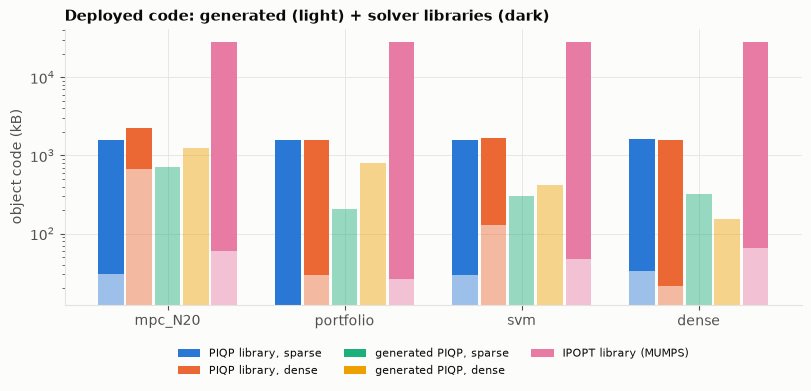

| case | solver | C lines | C source (kB) | object (kB) | libraries (kB) | workspace (kB) |
|---|---|---|---|---|---|---|
| `mpc_N20` | PIQP library, sparse | 1,641 | 129 | 30 | libpiqpc 1,568 | 0 |
| `mpc_N20` | PIQP library, dense | 228 | 300 | 678 | libpiqpc 1,568 | 0 |
| `mpc_N20` | generated PIQP, sparse | 4,601 | 760 | 707 | none | 483 |
| `mpc_N20` | generated PIQP, dense | 4,598 | 1,055 | 1,248 | none | 4,084 |
| `mpc_N20` | IPOPT library (MUMPS) | 2,067 | 225 | 60 | libipopt 24,883, libgfortran 3,254 | 0 |
| `portfolio` | PIQP library, sparse | 508 | 30 | 12 | libpiqpc 1,568 | 0 |
| `portfolio` | PIQP library, dense | 2,598 | 132 | 29 | libpiqpc 1,568 | 0 |
| `portfolio` | generated PIQP, sparse | 4,474 | 248 | 208 | none | 62 |
| `portfolio` | generated PIQP, dense | 4,419 | 614 | 803 | none | 421 |
| `portfolio` | IPOPT library (MUMPS) | 850 | 56 | 27 | libipopt 24,883, libgfortran 3,254 | 0 |
| `svm` | PIQP library, sparse | 1,169 | 80 | 30 | libpiqpc 1,568 | 0 |
| `svm` | PIQP library, dense | 290 | 60 | 127 | libpiqpc 1,568 | 108 |
| `svm` | generated PIQP, sparse | 4,274 | 335 | 302 | none | 373 |
| `svm` | generated PIQP, dense | 4,181 | 367 | 421 | none | 1,202 |
| `svm` | IPOPT library (MUMPS) | 1,461 | 122 | 47 | libipopt 24,883, libgfortran 3,254 | 0 |
| `dense` | PIQP library, sparse | 312 | 27 | 33 | libpiqpc 1,568 | 19 |
| `dense` | PIQP library, dense | 305 | 17 | 21 | libpiqpc 1,568 | 19 |
| `dense` | generated PIQP, sparse | 4,007 | 344 | 320 | none | 250 |
| `dense` | generated PIQP, dense | 3,998 | 217 | 155 | none | 105 |
| `dense` | IPOPT library (MUMPS) | 2,237 | 139 | 65 | libipopt 24,883, libgfortran 3,254 | 0 |

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.8))
width = 0.16
x = np.arange(len(CASES))
for j, key in enumerate(SOLVERS):
  gen = np.array([rows[(c, key)].get("object_bytes", np.nan) for c in CASES]) / 1e3
  lib = np.array([sum(rows[(c, key)].get("library_bytes", {}).values()) for c in CASES]) / 1e3
  pos = x + (j - 2) * width
  ax.bar(pos, gen, width * 0.9, color=COLOR[key], alpha=0.45, label=None)
  ax.bar(pos, lib, width * 0.9, bottom=gen, color=COLOR[key], label=LABEL[key])
ax.set_yscale("log")
ax.set_xticks(x, CASES)
ax.set_ylabel("object code (kB)")
ax.set_title("Deployed code: generated (light) + solver libraries (dark)")
ax.legend(ncols=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.show()

body = []
for case in CASES:
  for key in SOLVERS:
    r = rows[(case, key)]
    libs = ", ".join(f"{k.split('.so')[0]} {v / 1e3:,.0f}" for k, v in r["library_bytes"].items()) or "none"
    body.append([f"`{case}`", LABEL[key], f"{r['c_lines']:,}", f"{r['c_bytes'] / 1e3:,.0f}", f"{r['object_bytes'] / 1e3:,.0f}", libs, f"{8 * r['workspace_doubles'] / 1e3:,.0f}"])
table(["case", "solver", "C lines", "C source (kB)", "object (kB)", "libraries (kB)", "workspace (kB)"], body)

## What it costs to get a solver

Three stages, each timed in a fresh process: **build** (Python: proving the problem quadratic,
extracting its data, and for the generated PIQP tracing the algorithm over the structure),
**generate** (lowering and rendering C) and **compile** (`cc` with the JIT's flags, best of two).
The library solvers' own compile (PIQP, IPOPT, MUMPS…) is a one-off at install time, minutes, and is
not in these bars.

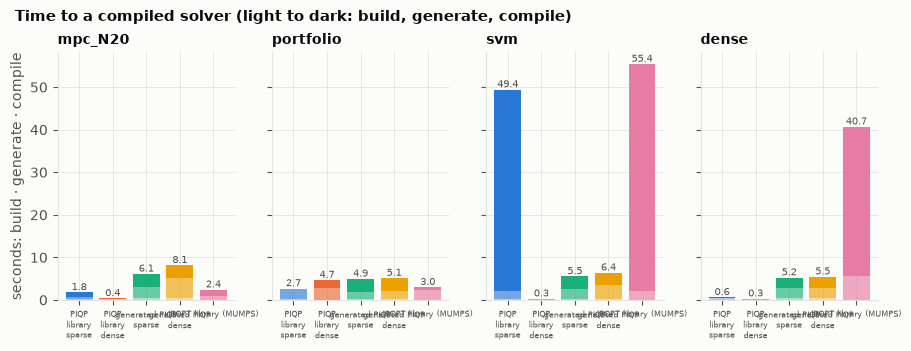

| case | solver | build (s) | generate (s) | compile (s) |
|---|---|---|---|---|
| `mpc_N20` | PIQP library, sparse | 0.32 | 0.43 | 1.01 |
| `mpc_N20` | PIQP library, dense | 0.11 | 0.04 | 0.22 |
| `mpc_N20` | generated PIQP, sparse | 0.38 | 2.73 | 3.00 |
| `mpc_N20` | generated PIQP, dense | 0.37 | 4.69 | 3.07 |
| `mpc_N20` | IPOPT library (MUMPS) | 0.03 | 0.84 | 1.53 |
| `portfolio` | PIQP library, sparse | 0.20 | 2.29 | 0.19 |
| `portfolio` | PIQP library, dense | 0.04 | 2.69 | 1.92 |
| `portfolio` | generated PIQP, sparse | 0.25 | 1.59 | 3.11 |
| `portfolio` | generated PIQP, dense | 0.24 | 1.75 | 3.13 |
| `portfolio` | IPOPT library (MUMPS) | 0.02 | 2.35 | 0.60 |
| `svm` | PIQP library, sparse | 0.23 | 1.96 | 47.23 |
| `svm` | PIQP library, dense | 0.08 | 0.02 | 0.17 |
| `svm` | generated PIQP, sparse | 0.30 | 2.22 | 3.00 |
| `svm` | generated PIQP, dense | 0.30 | 3.10 | 3.01 |
| `svm` | IPOPT library (MUMPS) | 0.02 | 2.07 | 53.33 |
| `dense` | PIQP library, sparse | 0.42 | 0.02 | 0.15 |
| `dense` | PIQP library, dense | 0.10 | 0.02 | 0.15 |
| `dense` | generated PIQP, sparse | 0.48 | 2.29 | 2.48 |
| `dense` | generated PIQP, dense | 0.49 | 2.36 | 2.62 |
| `dense` | IPOPT library (MUMPS) | 0.02 | 5.57 | 35.09 |

In [8]:
fig, axes = plt.subplots(1, len(CASES), figsize=(9, 3.4), sharey=True)
stages = [("build_s", 0.35), ("generate_s", 0.65), ("compile_s", 1.0)]
for ax, case in zip(axes, CASES):
  for j, key in enumerate(SOLVERS):
    r, bottom = rows[(case, key)], 0.0
    for stage, alpha in stages:
      ax.bar(j, r[stage], 0.8, bottom=bottom, color=COLOR[key], alpha=alpha)
      bottom += r[stage]
    ax.text(j, bottom, f"{bottom:.1f}", ha="center", va="bottom", fontsize=7, color=plotstyle.TEXT_SECONDARY)
  ax.set_title(case, fontsize=10)
  ax.set_xticks(range(len(SOLVERS)), [LABEL[k].replace("PIQP ", "PIQP\n").replace(", ", "\n") for k in SOLVERS], fontsize=6)
axes[0].set_ylabel("seconds: build · generate · compile")
fig.suptitle("Time to a compiled solver (light to dark: build, generate, compile)", x=0.01, ha="left", fontweight="bold", fontsize=11)
plt.show()

body = [[f"`{c}`", LABEL[k], f"{rows[(c, k)]['build_s']:.2f}", f"{rows[(c, k)]['generate_s']:.2f}", f"{rows[(c, k)]['compile_s']:.2f}"] for c in CASES for k in SOLVERS]
table(["case", "solver", "build (s)", "generate (s)", "compile (s)"], body)

## Solve time

One cold solve, called from C: best and median over as many repetitions as fit in two seconds (at
least five). The Python `Function` call adds a few microseconds on top (last column, best).

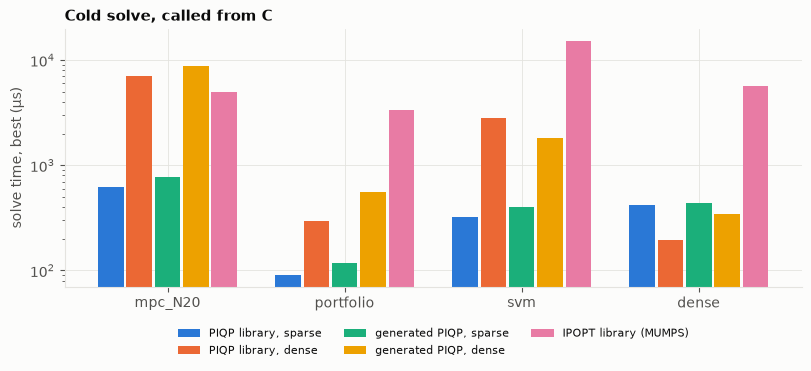

| case | solver | iterations | C best | C median | vs PIQP library sparse | Python call |
|---|---|---|---|---|---|---|
| `mpc_N20` | PIQP library, sparse | 9 | 621 µs | 655 µs | 1.00× | 648 µs |
| `mpc_N20` | PIQP library, dense | 9 | 7,124 µs | 7,272 µs | 11.48× | 6,942 µs |
| `mpc_N20` | generated PIQP, sparse | 9 | 775 µs | 811 µs | 1.25× | 825 µs |
| `mpc_N20` | generated PIQP, dense | 9 | 8,766 µs | 9,021 µs | 14.13× | 8,842 µs |
| `mpc_N20` | IPOPT library (MUMPS) | 11 | 4,986 µs | 5,175 µs | 8.04× | 5,185 µs |
| `portfolio` | PIQP library, sparse | 7 | 91 µs | 93 µs | 1.00× | 129 µs |
| `portfolio` | PIQP library, dense | 7 | 298 µs | 316 µs | 3.29× | 344 µs |
| `portfolio` | generated PIQP, sparse | 7 | 118 µs | 123 µs | 1.30× | 143 µs |
| `portfolio` | generated PIQP, dense | 7 | 562 µs | 592 µs | 6.21× | 614 µs |
| `portfolio` | IPOPT library (MUMPS) | 15 | 3,361 µs | 3,581 µs | 37.13× | 3,522 µs |
| `svm` | PIQP library, sparse | 10 | 325 µs | 355 µs | 1.00× | 372 µs |
| `svm` | PIQP library, dense | 10 | 2,792 µs | 2,876 µs | 8.59× | 2,914 µs |
| `svm` | generated PIQP, sparse | 10 | 400 µs | 418 µs | 1.23× | 435 µs |
| `svm` | generated PIQP, dense | 10 | 1,806 µs | 1,936 µs | 5.56× | 1,863 µs |
| `svm` | IPOPT library (MUMPS) | 26 | 15.3 ms | 16.5 ms | 47.11× | 14.2 ms |
| `dense` | PIQP library, sparse | 8 | 417 µs | 445 µs | 1.00× | 457 µs |
| `dense` | PIQP library, dense | 8 | 195 µs | 212 µs | 0.47× | 228 µs |
| `dense` | generated PIQP, sparse | 8 | 443 µs | 470 µs | 1.06× | 485 µs |
| `dense` | generated PIQP, dense | 8 | 344 µs | 381 µs | 0.82× | 377 µs |
| `dense` | IPOPT library (MUMPS) | 15 | 5,650 µs | 5,921 µs | 13.55× | 5,755 µs |
| `mpc_N5` | PIQP library, sparse | 8 | 132 µs | 139 µs | 1.00× | 162 µs |
| `mpc_N5` | PIQP library, dense | 8 | 291 µs | 309 µs | 2.21× | 328 µs |
| `mpc_N5` | generated PIQP, sparse | 8 | 172 µs | 182 µs | 1.31× | 193 µs |
| `mpc_N5` | generated PIQP, dense | 8 | 350 µs | 366 µs | 2.66× | 375 µs |
| `mpc_N5` | IPOPT library (MUMPS) | 10 | 3,016 µs | 3,248 µs | 22.91× | 2,760 µs |
| `mpc_N10` | PIQP library, sparse | 9 | 308 µs | 321 µs | 1.00× | 343 µs |
| `mpc_N10` | PIQP library, dense | 9 | 1,335 µs | 1,379 µs | 4.34× | 1,404 µs |
| `mpc_N10` | generated PIQP, sparse | 9 | 399 µs | 415 µs | 1.30× | 425 µs |
| `mpc_N10` | generated PIQP, dense | 9 | 1,440 µs | 1,500 µs | 4.68× | 1,494 µs |
| `mpc_N10` | IPOPT library (MUMPS) | 11 | 3,376 µs | 3,572 µs | 10.98× | 3,595 µs |
| `mpc_N40` | PIQP library, sparse | 9 | 1,259 µs | 1,300 µs | 1.00× | 1,302 µs |
| `mpc_N40` | PIQP library, dense | 9 | 44.8 ms | 45.7 ms | 35.53× | 43.6 ms |
| `mpc_N40` | generated PIQP, sparse | 9 | 1,738 µs | 1,802 µs | 1.38× | 1,777 µs |
| `mpc_N40` | generated PIQP, dense | 9 | 60.0 ms | 60.7 ms | 47.63× | 58.9 ms |
| `mpc_N40` | IPOPT library (MUMPS) | 11 | 7,759 µs | 8,682 µs | 6.16× | 7,852 µs |

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.6))
for j, key in enumerate(SOLVERS):
  best = [rows[(c, key)]["c_best_s"] * 1e6 for c in CASES]
  pos = np.arange(len(CASES)) + (j - 2) * width
  ax.bar(pos, best, width * 0.9, color=COLOR[key], label=LABEL[key])
ax.set_yscale("log")
ax.set_xticks(np.arange(len(CASES)), CASES)
ax.set_ylabel("solve time, best (µs)")
ax.set_title("Cold solve, called from C")
ax.legend(ncols=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.show()

body = []
for case in CASES + ["mpc_N5", "mpc_N10", "mpc_N40"]:
  base = rows[(case, "piqp_sparse")]["c_best_s"]
  for key in SOLVERS:
    r = rows[(case, key)]
    body.append([f"`{case}`", LABEL[key], r["iterations"], us(r["c_best_s"]), us(r["c_median_s"]), f"{r['c_best_s'] / base:.2f}×", us(r["python_best_s"])])
table(["case", "solver", "iterations", "C best", "C median", "vs PIQP library sparse", "Python call"], body)

## Scaling with the horizon

The MPC problem at $N = 5, 10, 20, 40$: the number of variables grows linearly in $N$, and so should
the sparse solvers' work per iteration, while the dense backends factor an $n \times n$ condensed
matrix, $O(N^3)$. The generated sparse PIQP keeps its loops as loops (the factorization is a
column scan over constant index tables), so its C should grow far more slowly than the problem.

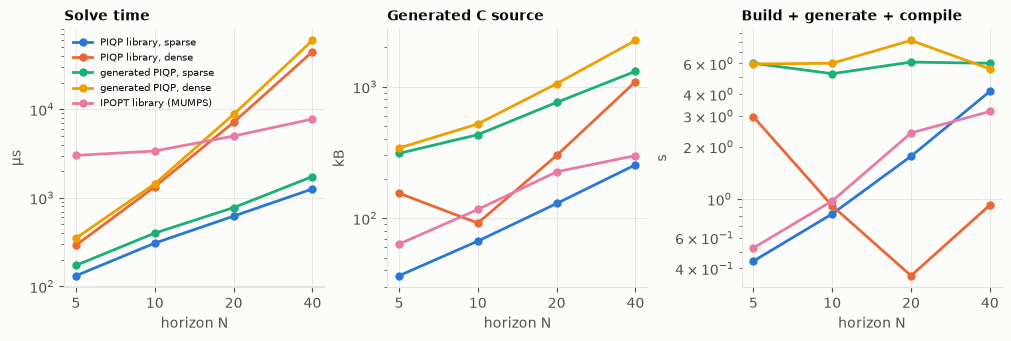

In [10]:
horizon = np.array([5, 10, 20, 40])
fig, axes = plt.subplots(1, 3, figsize=(10, 3.3))
for key in SOLVERS:
  rs = [rows[(c, key)] for c in SWEEP]
  kw = dict(color=COLOR[key], marker="o", label=LABEL[key])
  axes[0].plot(horizon, [r["c_best_s"] * 1e6 for r in rs], **kw)
  axes[1].plot(horizon, [r["c_bytes"] / 1e3 for r in rs], **kw)
  axes[2].plot(horizon, [r["build_s"] + r["generate_s"] + r["compile_s"] for r in rs], **kw)
for ax, title, unit in zip(axes, ["Solve time", "Generated C source", "Build + generate + compile"], ["µs", "kB", "s"]):
  ax.set_xscale("log", base=2)
  ax.set_yscale("log")
  ax.set_xticks(horizon, horizon)
  ax.set_xlabel("horizon N")
  ax.set_ylabel(unit)
  ax.set_title(title, fontsize=10)
axes[0].legend(fontsize=7)
plt.show()

## Summary

In [11]:
def gmean(v):
  return float(np.exp(np.mean(np.log(v))))


names = CASES + ["mpc_N5", "mpc_N10", "mpc_N40"]
for backend in ("sparse", "dense"):
  ratio = [rows[(c, f"scaly_{backend}")]["c_best_s"] / rows[(c, f"piqp_{backend}")]["c_best_s"] for c in names]
  print(f"generated / library PIQP solve time, {backend}: geometric mean {gmean(ratio):.2f}×, range {min(ratio):.2f}–{max(ratio):.2f}×")
ratio = [rows[(c, "ipopt")]["c_best_s"] / rows[(c, "scaly_sparse")]["c_best_s"] for c in names]
print(f"IPOPT / generated sparse PIQP solve time: geometric mean {gmean(ratio):.1f}×")
deployed = [
  (rows[(c, "piqp_sparse")]["object_bytes"] + sum(rows[(c, "piqp_sparse")]["library_bytes"].values())) / rows[(c, "scaly_sparse")]["object_bytes"] for c in names
]
print(f"deployed code, PIQP library (wrapper + libpiqpc) / generated sparse PIQP: {min(deployed):.1f}–{max(deployed):.1f}×")
t_gen = [rows[(c, "scaly_sparse")]["build_s"] + rows[(c, "scaly_sparse")]["generate_s"] + rows[(c, "scaly_sparse")]["compile_s"] for c in names]
print(f"time to a compiled generated sparse PIQP: {min(t_gen):.1f}–{max(t_gen):.1f} s")

generated / library PIQP solve time, sparse: geometric mean 1.26×, range 1.06–1.38×
generated / library PIQP solve time, dense: geometric mean 1.24×, range 0.65–1.89×
IPOPT / generated sparse PIQP solve time: geometric mean 12.9×
deployed code, PIQP library (wrapper + libpiqpc) / generated sparse PIQP: 1.3–7.6×
time to a compiled generated sparse PIQP: 4.9–6.1 s


Reading the numbers:

- **Same algorithm, same answers.** The generated PIQP is held to PIQP 0.6.2's decision trace in
  the test suite (Tier 3); here it takes the library's iterations and returns its solution to the
  tolerance on every problem.
- **Speed.** With the sparse backend, the generated solver is within a small factor of the library,
  on problems where the KKT factorization dominates. The dense backend's condensed Cholesky is the
  known gap (todo C-117), as is the padding in the sparse factor updates (C-114).
- **What ships.** The generated PIQP is one self-contained C file, a few hundred kB of object code
  specialised to one structure; the library route ships the PIQP library (C++, Eigen, BLASFEO) next
  to a small wrapper, and IPOPT adds MUMPS, METIS, BLAS and a Fortran runtime.
- **What it costs.** The generated solver takes a few seconds to trace, render and compile, where a
  library wrapper usually takes well under one. The exception is GCC on the wrappers' straight-line
  oracle code: here GCC 13 spends 35–53 s compiling the `svm` and `dense` oracles for PIQP and IPOPT,
  almost all of it in its `tree VRP` pass after SLP vectorization (clang compiles the `svm` PIQP
  wrapper in about a second). The generated solver, whose loops stay loops, does not hit it.
- **Portfolio.** All solvers agree on the objective to 1e-9, but `x` differs at 1e-4: the problem is
  nearly degenerate (several portfolios within the tolerance of the optimum), not a solver error.
- **IPOPT** is a general NLP solver with an exact-Hessian filter line search: on QPs it solves the
  same problems, in more iterations and at a higher cost per iteration, and it carries the largest
  runtime.

## References

- R. Schwan, Y. Jiang, D. Kuhn, C. N. Jones, "PIQP: A Proximal Interior-Point Quadratic Programming
  Solver," *IEEE CDC* 2023. [arXiv:2304.00290](https://arxiv.org/abs/2304.00290)
- A. Wächter, L. T. Biegler, "On the implementation of an interior-point filter line-search algorithm
  for large-scale nonlinear programming," *Mathematical Programming* 106 (2006), 25–57.
  [doi:10.1007/s10107-004-0559-y](https://doi.org/10.1007/s10107-004-0559-y)
- S. Mehrotra, "On the implementation of a primal-dual interior point method," *SIAM Journal on
  Optimization* 2(4) (1992), 575–601. [doi:10.1137/0802028](https://doi.org/10.1137/0802028)
- D. Ruiz, "A scaling algorithm to equilibrate both rows and columns norms in matrices," Rutherford
  Appleton Laboratory report RAL-TR-2001-034 (2001).
- T. A. Davis, "Algorithm 849: A concise sparse Cholesky factorization package," *ACM TOMS* 31(4)
  (2005), 587–591. [doi:10.1145/1114268.1114277](https://doi.org/10.1145/1114268.1114277)